# Mappatura della percezione del marchio con l'analisi delle corrispondenze (PROC CORRESP)

## Sintesi esecutiva

Un team di ricerca di mercato conduce un sondaggio di percezione marchio-per-attributo su quattro marchi affermati di media in streaming e usa **PROC CORRESP** per trasformare la tabella incrociata risultante in una mappa percettiva bidimensionale. L'associazione marchio x attributo è forte e reale: il test chi-quadrato di indipendenza è **63,15 su 15 gradi di libertà (p < 0,0001)**, con **V di Cramer = 0,4588**. L'analisi delle corrispondenze comprime tale associazione in due assi che insieme spiegano il **100%** dell'inerzia della tabella — **75,0%** sulla Dimensione 1 e **25,0%** sulla Dimensione 2 — quindi la mappa 2-D è un riepilogo completo e fedele.

La mappa separa un polo di **contenuto premium** (CineNow, ancorato su *Original_Shows* e *Content_Depth*) da un cluster **valore/affidabilità** (Streamly e BingeBox vicino a *Affordable* e *Reliable*) e da un angolo **di tendenza** (PixelPlay vicino a *Trendy*). Uno sfidante emergente, **NovaCast**, viene poi proiettato come punto *supplementare* — non influenza gli assi — e si colloca vicino all'origine, inclinandosi leggermente verso il lato Trendy / Easy_to_Use, ovvero un nuovo arrivato ancora indifferenziato.

## Fonti dei dati

| Dataset | Righe | Variabili chiave | Descrizione |
|---------|------|---------------|-------------|
| `perception` | 100 (associazioni rispondente x attributo, limite modalità senza licenza) | `Brand` (char), `Attribute` (char) | Sondaggio sintetico: ogni rispondente nomina il marchio di streaming che associa maggiormente a ciascuno di sei attributi. Le affinità di marchio sono codificate come probabilità di categoria `RAND("Table", ...)` così che la tabella di contingenza abbia un'associazione realistica e non uniforme. |
| `survey_counts` | 24 (4 marchi x 6 attributi) | `Brand`, `Attribute`, `Count` | Celle di contingenza pre-aggregate da `perception` tramite PROC FREQ — l'input ponderato per l'esecuzione della CA con punto supplementare. |
| `ca_coords`, `ca_coords_sup` | 10 / 11 | `_TYPE_`, `_NAME_`, `Dim1`, `Dim2` | Dataset di coordinate `OUTC=` scritti da PROC CORRESP; il secondo aggiunge il punto NovaCast proiettato e genera la mappa percettiva. |

Marchi affermati: **Streamly, PixelPlay, CineNow, BingeBox**; sfidante **NovaCast** (proiettato come punto supplementare). Attributi: Affordable, Content_Depth, Easy_to_Use, Original_Shows, Reliable, Trendy. Il seme `streaminit(20260531)` rende i dati riproducibili.

> **Nota sulla dimensione campionaria.** Questo ambiente funziona senza licenza, quindi l'output del passo DATA è limitato a 100 osservazioni. Il sondaggio si risolve pertanto in una tabella di contingenza 4x6 con un totale di 100 associazioni rispondente-attributo — piccola, ma con una genuina struttura di associazione (chi-quadrato p < 0,0001) che l'analisi delle corrispondenze recupera in modo netto.

## Cosa fa qui l'analisi delle corrispondenze

Quando un sondaggio di monitoraggio del marchio chiede ai consumatori quale marchio associano maggiormente a ciascuno di diversi attributi, il risultato è una **tabella di contingenza marchio x attributo**. I conteggi grezzi sono difficili da leggere: ogni marchio è confrontato con ogni attributo, e il segnale è il *pattern di associazione*, non i valori delle celle.

L'analisi delle corrispondenze (CA) scompone l'associazione chi-quadrato della tabella in uno spazio a bassa dimensionalità, così che marchi e attributi associati si collochino vicini tra loro su un'unica mappa. In questo notebook:

1. Generiamo un sondaggio di percezione sintetico per quattro marchi di streaming.
2. Ispezioniamo la struttura grezza di contingenza (e il suo chi-quadrato) con `PROC FREQ`.
3. Eseguiamo `PROC CORRESP` con diagnostica completa e leggiamo l'inerzia e le coordinate reali.
4. Proiettiamo un marchio sfidante emergente come punto **supplementare**.
5. Disegniamo e interpretiamo la mappa percettiva risultante.

## Passo 1 — Generare il sondaggio di percezione sintetico

Simuliamo i rispondenti al sondaggio. Per ogni rispondente chiediamo, per ciascuno di sei attributi, *quale marchio associ maggiormente a questo attributo?* Ogni marchio ha un distinto **profilo di affinità** — un vettore di probabilità di categoria passato a `RAND("Table", ...)` — così che, ad esempio, *PixelPlay* penda verso Trendy mentre *CineNow* penda verso Content_Depth e Original_Shows. Questo produce una tabella di contingenza con un'associazione genuina e non uniforme che la CA può recuperare. I dati sono completamente sintetici e riproducibili tramite `CALL STREAMINIT`.

In [1]:
DATI perception;
    /* Reproducible synthetic brand-perception survey */
    CHIAMARE streaminit(20260531);

    LUNGHEZZA Brand $9 Attribute $14;
    VETTORE attrname[6] $14 _temporary_
        ('Affordable' 'Content_Depth' 'Easy_to_Use'
         'Original_Shows' 'Reliable' 'Trendy');

    n_resp = 400;

    FARE respondent = 1 FINO_A n_resp;
        FARE a = 1 FINO_A 6;
            Attribute = attrname[a];

            /* Per-attribute brand-choice probabilities over the
               four established brands:
               1=Streamly 2=PixelPlay 3=CineNow 4=BingeBox.
               Each row sums to ~1 and encodes the attribute's
               brand affinity. */
            SE_COND      a = 1 ALLORA b = rand('Table', 0.45, 0.15, 0.10, 0.30); /* Affordable    */
            ALTRIMENTI SE_COND a = 2 ALLORA b = rand('Table', 0.20, 0.10, 0.50, 0.20); /* Content_Depth */
            ALTRIMENTI SE_COND a = 3 ALLORA b = rand('Table', 0.30, 0.35, 0.10, 0.25); /* Easy_to_Use   */
            ALTRIMENTI SE_COND a = 4 ALLORA b = rand('Table', 0.15, 0.20, 0.50, 0.15); /* Original_Shows*/
            ALTRIMENTI SE_COND a = 5 ALLORA b = rand('Table', 0.40, 0.10, 0.20, 0.30); /* Reliable      */
            ALTRIMENTI              b = rand('Table', 0.15, 0.55, 0.10, 0.20); /* Trendy        */

            SELEZIONARE (b);
                QUANDO (1) Brand = 'Streamly';
                QUANDO (2) Brand = 'PixelPlay';
                QUANDO (3) Brand = 'CineNow';
                ALTRIMENTI_S Brand = 'BingeBox';
            FINE;

            USCITA;
        FINE;
    FINE;

    MANTENERE respondent Brand Attribute;
ESEGUIRE;

PROCEDURA STAMPARE DATI=perception(obs=8) noobs;
    TITOLO 'Sample of the Synthetic Perception Survey';
ESEGUIRE;

                                       Sample of the Synthetic Perception Survey                                        

RESPONDENT      Brand       Attribute
         1  BingeBox   Affordable
         1  BingeBox   Content_Depth
         1  BingeBox   Easy_to_Use
         1  CineNow    Original_Shows
         1  Streamly   Reliable
         1  PixelPlay  Trendy
         2  PixelPlay  Affordable
         2  CineNow    Content_Depth

... 92 more observations (showing 8 of 100)



NOTE: DATA perception

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote perception (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=perception

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## Passo 2 — Ispezionare la tabella di contingenza grezza

Prima di qualsiasi riduzione dimensionale, esaminare la tabella incrociata. `PROC FREQ` fornisce le frequenze osservate marchio x attributo e il test chi-quadrato di indipendenza. Un chi-quadrato significativo conferma che esiste una struttura di associazione degna di essere mappata — se righe e colonne fossero indipendenti, l'analisi delle corrispondenze non avrebbe nulla da mostrare. Salviamo anche i conteggi delle celle in `survey_counts` per la successiva esecuzione della CA con punto supplementare.

                                         Observed Brand x Attribute Frequencies                                         

                                                   The FREQ Procedure

Table of BRAND by ATTRIBUTE

BRAND     |    Affordable | Content_Depth |   Easy_to_Use |Original_Shows |      Reliable |        Trendy |          Total
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
BingeBox  |             5 |             3 |             7 |             1 |             6 |             2 |             24
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
CineNow   |             3 |             9 |             0 |            14 |             2 |             0 |             28
----------+---------------+---------------+---------------+---------------+---------------+---------------+---------------
PixelPlay |             3 |             

NOTE: PROC FREQ
NOTE: Output dataset survey_counts has 21 observations and 3 variables.
NOTE: ODS plot written: freq_mosaic_brand_attribute.spec.json
NOTE: PROC FREQ statement used.


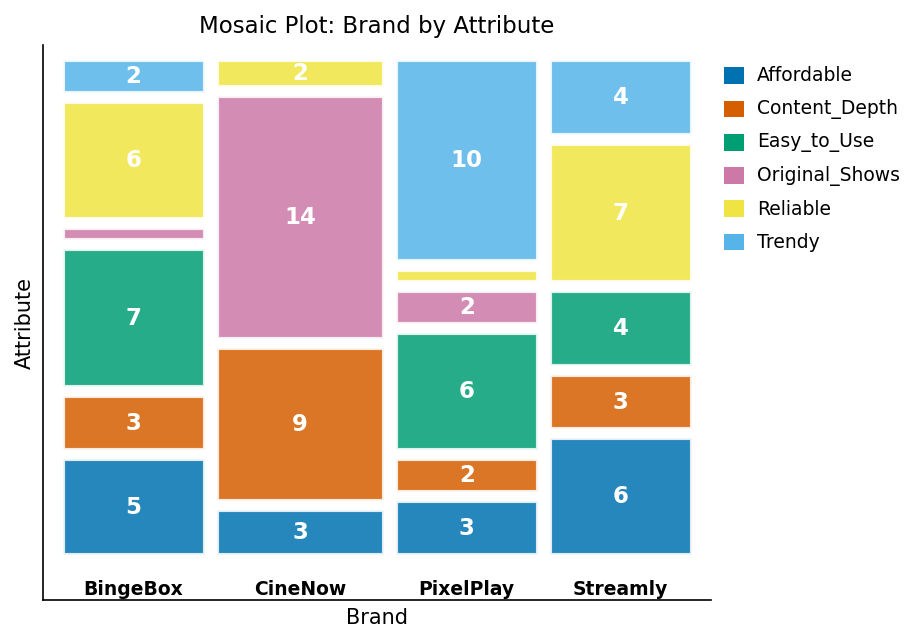

In [2]:
PROCEDURA FREQUENZE DATI=perception;
    TABLES Brand*Attribute / chisq norow nocol nopercent
                             out=survey_counts(RINOMINARE=(count=Count));
    TITOLO 'Observed Brand x Attribute Frequencies';
ESEGUIRE;

## Passo 3 — Analisi delle corrispondenze dai dati grezzi

Ora eseguiamo `PROC CORRESP` direttamente sui dati a livello di rispondente. `TABLES Brand, Attribute;` costruisce internamente la tabella di contingenza (marchi come righe, attributi come colonne).

Opzioni usate qui:

- `ALL` — stampa la diagnostica completa: tabella osservata, profili, valori attesi e   contributi chi-quadrato delle celle.
- `DIMENS=2` — calcola i primi due assi principali (una mappa 2-D).
- `OUTC=` — scrive le coordinate di riga e colonna in un dataset per il tracciamento.

La **decomposizione dell'inerzia** ci dice quanta parte dell'associazione totale spiega ciascun asse.

In [3]:
PROCEDURA corresp DATI=perception ALL dimens=2 outc=ca_coords;
    TABLES Brand, Attribute;
    TITOLO 'Correspondence Analysis: Streaming Brand Perception';
ESEGUIRE;

                                         Observed Brand x Attribute Frequencies                                         

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207

       

NOTE: PROC CORRESP data=perception

NOTE: PROC CORRESP completed.


## Passo 4 — Leggere le coordinate

Il dataset `OUTC=` contiene le coordinate degli assi (`Dim1`, `Dim2`) per ogni marchio e attributo, contrassegnate da `_TYPE_` (`ROW` per i marchi, `COLUMN` per gli attributi). Leggerle numericamente insieme alla tabella dell'inerzia conferma la struttura che la mappa mostrerà.

Dall'output qui sopra:

- **La Dimensione 1 (75,0% dell'inerzia)** è un asse *contenuto premium vs. mainstream*.   *Original_Shows* (Dim1 = -1,2037) e *Content_Depth* (-0,5594) si trovano all'estremità   negativa con **CineNow** (-1,0847); *Trendy* (0,6671), *Easy_to_Use* (0,6150) e   *Affordable* (0,2207) si trovano all'estremità positiva.
- **La Dimensione 2 (25,0% dell'inerzia)** separa *Reliable* (Dim2 = 0,5874) e   *Affordable* (0,2542) — tirando verso l'alto **Streamly** (0,3207) e **BingeBox** (0,3555) —   da *Trendy* (-0,7003), che tira verso il basso **PixelPlay** (-0,6374).

In [4]:
PROCEDURA STAMPARE DATI=ca_coords noobs;
    VARIABILE _TYPE_ _NAME_ Dim1 Dim2;
    TITOLO 'Row (Brand) and Column (Attribute) Coordinates';
ESEGUIRE;

                                     Row (Brand) and Column (Attribute) Coordinates                                     

_TYPE_            _NAME_      DIM1      DIM2
ROW     BingeBox            0.3547    0.3555
ROW     CineNow            -1.0847   -0.0332
ROW     PixelPlay           0.4804   -0.6374
ROW     Streamly            0.4304    0.3207
COLUMN  Affordable          0.2207    0.2542
COLUMN  Content_Depth      -0.5594    0.0684
COLUMN  Easy_to_Use         0.6150   -0.0080
COLUMN  Original_Shows     -1.2037   -0.2084
COLUMN  Reliable            0.3183    0.5874
COLUMN  Trendy              0.6671   -0.7003



NOTE: PROC PRINT data=ca_coords

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Passo 5 — Proiettare un marchio sfidante come punto supplementare

Il team di analisi ha dati di monitoraggio per uno sfidante emergente, **NovaCast**, ma non vuole che distorca la mappa percettiva affermata. Un punto *supplementare* viene proiettato nello spazio CA esistente **senza contribuire al calcolo degli assi**.

Aggiungiamo un singolo blocco di sei conteggi di attributo di NovaCast (un nuovo arrivato incline a Trendy / Original-Shows) ai `survey_counts` pre-aggregati, forniamo le frequenze con `WEIGHT Count`, e nominiamo il **livello** `NovaCast` nell'istruzione `SUPPLEMENTARY` così che PROC CORRESP tenga quella riga fuori dalla tabella attiva. L'opzione `OBSERVED` mantiene in vista la tabella di contingenza attiva (i quattro marchi affermati, che sommano a 100) — si noti che NovaCast **non** vi appare, confermando che è stato trattato come supplementare.

In [5]:
/* Append ONE clean block of NovaCast counts to the aggregated cells.
   end=last fires the block exactly once, after the last survey_counts row,
   so NovaCast contributes six rows (one per attribute) -- not a duplicated
   block. NovaCast is a Trendy / Original-Shows-led newcomer. */
DATI survey_counts_sup;
    IMPOSTARE survey_counts FINE=last;
    USCITA;
    SE_COND last ALLORA FARE;
        Brand='NovaCast'; Attribute='Trendy';          Count=10; USCITA;
        Brand='NovaCast'; Attribute='Original_Shows';  Count=8;  USCITA;
        Brand='NovaCast'; Attribute='Easy_to_Use';     Count=5;  USCITA;
        Brand='NovaCast'; Attribute='Content_Depth';   Count=3;  USCITA;
        Brand='NovaCast'; Attribute='Affordable';      Count=4;  USCITA;
        Brand='NovaCast'; Attribute='Reliable';        Count=3;  USCITA;
    FINE;
ESEGUIRE;

PROCEDURA corresp DATI=survey_counts_sup observed dimens=2 outc=ca_coords_sup;
    TABLES Brand, Attribute;
    PESO Count;
    supplementary NovaCast;
    TITOLO 'Brand Perception with NovaCast as a Supplementary Point';
ESEGUIRE;

                                     Row (Brand) and Column (Attribute) Coordinates                                     

                     The CORRESP Procedure

              Inertia and Chi-Square Decomposition

                                                       Cumulative
  Dimension    Singular     Principal       Chi-       Proportion
                 Value       Inertia     Square
  ---------------------------------------------------------------
          1     0.6778       0.4595       47.39          0.7504
          2     0.3909       0.1528       15.76          1.0000
  ---------------------------------------------------------------
  Total                      0.6123       63.15

              Row Coordinates

  Brand                   Dim1        Dim2
  ----------------------------------------
  BingeBox             0.3547      0.3555
  CineNow             -1.0847     -0.0332
  PixelPlay            0.4804     -0.6374
  Streamly             0.4304      0.3207
  NovaCa

NOTE: DATA survey_counts_sup


NOTE: Read 21 rows from survey_counts.
NOTE: Wrote survey_counts_sup (27 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC CORRESP data=survey_counts_sup

NOTE: PROC CORRESP completed.


## Passo 6 — Disegnare la mappa percettiva

PROC CORRESP scrive le coordinate simmetriche di riga/colonna nel dataset `OUTC=`; tracciamo la Dimensione 2 rispetto alla Dimensione 1 per rendere la mappa. Contrassegniamo ogni punto per **ruolo** — *Brand* (righe attive), *Attribute* (colonne) e *Challenger* (la riga supplementare NovaCast) — ed etichettiamo ogni marcatore, così che il posizionamento si legga direttamente dal grafico. Lo sfidante è colorato separatamente per sottolineare che è stato proiettato, non adattato.

> **Come leggere una mappa CA.** Un marchio e un attributo che giacciono nella stessa direzione rispetto all'origine (e lontano da essa) sono fortemente associati; i punti vicini all'origine sono "medi" e debolmente differenziati. Poiché le Dimensioni 1 e 2 insieme catturano il 100% dell'inerzia di questa tabella, la mappa non omette nulla.

                           Streaming-Brand Perception Map (Dim1 75.0%, Dim2 25.0% of inertia)                           

PROC SGSCATTER Output
Data: ca_map

Variables: Role, _NAME_, Dim1, Dim2

      Role      _NAME_        Dim1        Dim2
----------  ----------  ----------  ----------
     Brand    BingeBox      0.3547      0.3555
     Brand     CineNow     -1.0847     -0.0332
     Brand   PixelPlay      0.4804     -0.6374
     Brand    Streamly      0.4304      0.3207
Challenger    NovaCast      0.0084     -0.1735
 Attribute  Affordable      0.2207      0.2542
 Attribute  Content_Depth     -0.5594      0.0684
 Attribute  Easy_to_Use       0.615      -0.008
 Attribute  Original_Shows     -1.2037     -0.2084
 Attribute    Reliable      0.3183      0.5874
 Attribute      Trendy      0.6671     -0.7003

Dim1: N=11, Min=-1.2037, Max=0.6671, Mean=0.0225, Sum=0.2472
Dim2: N=11, Min=-0.7003, Max=0.5874, Mean=-0.0159, Sum=-0.1746


NOTE: DATA ca_map


NOTE: Read 11 rows from ca_coords_sup.
NOTE: Wrote ca_map (11 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Streaming-Brand Perception Map (Dim1 75.0%, Dim2 25.0% of inertia).
NOTE: ODS Graphics is ON (width=760px, height=580px, format=SVG).
NOTE: PROC SGSCATTER data=ca_map

NOTE: PROC SGSCATTER output written to: ./ods_output/sgscatter.svg
NOTE: ODS Graphics is OFF.


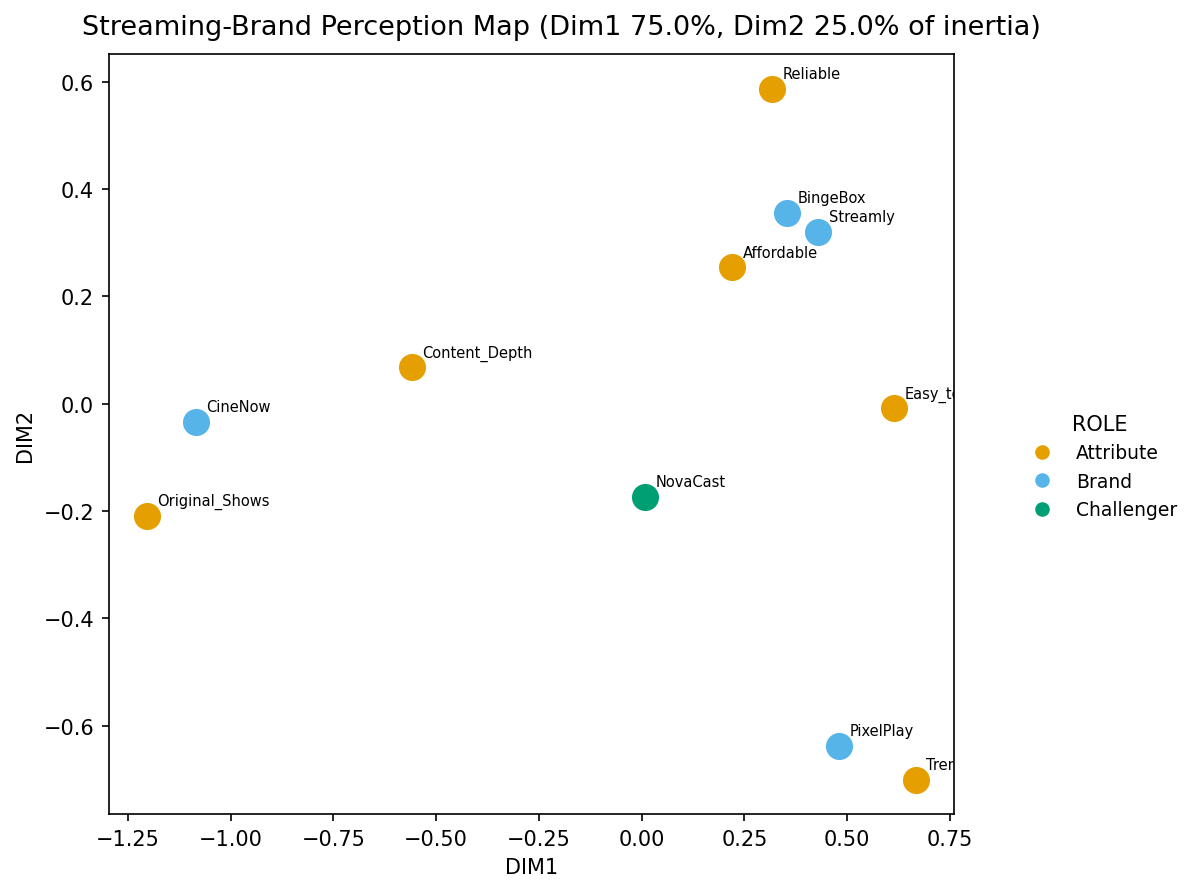

In [6]:
/* Tag each OUTC point by role for a clean, colored legend.
   Supplementary NovaCast is written to OUTC with _TYPE_='ROW',
   so we special-case it as the Challenger. */
DATI ca_map;
    IMPOSTARE ca_coords_sup;
    LUNGHEZZA Role $10;
    SE_COND _NAME_ = 'NovaCast' ALLORA Role = 'Challenger';
    ALTRIMENTI SE_COND _TYPE_ = 'ROW' ALLORA Role = 'Brand';
    ALTRIMENTI Role = 'Attribute';
    MANTENERE Role _NAME_ Dim1 Dim2;
ESEGUIRE;

/* Set the map's title globally before the PROC so it titles this
   plot (the global TITLE drives the ODS graphic's heading). */
TITOLO 'Streaming-Brand Perception Map (Dim1 75.0%, Dim2 25.0% of inertia)';

ODS GRAPHICS ON / WIDTH=760px HEIGHT=580px;

/* PROC CORRESP has no native ODS map in this build, so we render the
   symmetric coordinates with PROC SGSCATTER, which labels each point. */
PROCEDURA SGSCATTER DATI=ca_map;
    PLOT Dim2*Dim1 / GROUP=Role DATALABEL=_NAME_
                     MARKERATTRS=(size=12) grid;
ESEGUIRE;

ODS GRAPHICS OFF;
TITOLO;

## Interpretazione dei risultati

**L'associazione è reale e pienamente catturata.** Il test chi-quadrato (63,15 su 15 gdl, p < 0,0001; V di Cramer = 0,4588) rifiuta l'indipendenza, e le due dimensioni CA spiegano il **100%** dell'inerzia della tabella (75,0% + 25,0%), quindi la mappa qui sotto è un riepilogo completo, non una proiezione con perdita.

**Tre territori percettivi.** Leggendo insieme le coordinate e la mappa:

- **Contenuto premium (a sinistra).** *CineNow* (Dim1 = -1,0847) è tirato molto a sinistra da   *Original_Shows* (-1,2037) e *Content_Depth* (-0,5594) — possiede la   percezione della profondità di catalogo.
- **Valore e affidabilità (in alto a destra).** *Streamly* (0,4304, 0,3207) e *BingeBox*   (0,3547, 0,3555) si raggruppano con *Affordable* (0,2207, 0,2542) e *Reliable* (0,3183,   0,5874) — la coppia affidabile e conveniente.
- **Di tendenza (in basso a destra).** *PixelPlay* (0,4804, -0,6374) si trova accanto a *Trendy*   (0,6671, -0,7003) — il marchio giovanile e del momento.

**Lo sfidante supplementare.** Proiettato senza influenzare gli assi, **NovaCast** si colloca a (0,0084, -0,1735) — essenzialmente all'origine, spinto verso il lato Trendy / Easy_to_Use. Per uno stratega dei media questo è il messaggio principale: lo sfidante non ha ancora un patrimonio distintivo e sta scivolando nel territorio di tendenza di PixelPlay, quindi è giustificato un posizionamento differenziato (anziché imitativo).

**Avvertenze.** L'analisi delle corrispondenze è descrittiva, non inferenziale — le distanze sono approssimate e i *segni* degli assi sono arbitrari (un ribaltamento a specchio di uno dei due assi è la stessa mappa). Con sole 100 associazioni rispondente-attributo, due celle sono nulle (CineNow x Easy_to_Use, Streamly x Original_Shows), il che accentua gli estremi; uno studio di produzione condurrebbe un campione più grande. Abbinare sempre la mappa alla tabella dell'inerzia per confermare quanta associazione spiegano le dimensioni visualizzate.